# Introducción a series de tiempo con volatilidad 

In [2]:
import numpy as np

In [3]:
random = np.random.rand(2, 3)

print(random)

[[0.97921167 0.11867298 0.11518063]
 [0.19903513 0.52659248 0.48758601]]


In [5]:
import scipy as sp 

t=np.zeros(100)
t

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

C:\Users\diego leon\AppData\Local\Temp\ipykernel_20200\1873501525.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t[0]=np.random.normal(0,np.sqrt(a[0]/(1-a[1])),1)


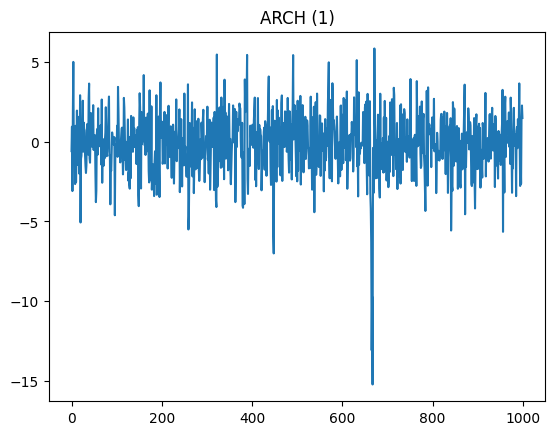

In [7]:
import matplotlib.pyplot as plt

np.random.seed(123)
n=1000        
n1=100        
n2=n+n1       

a=(2,0.5)  # a0=2 a1=0.5
errors=np.random.normal(0,1,n2) 
t=np.zeros(n2)
t[0]=np.random.normal(0,np.sqrt(a[0]/(1-a[1])),1) 
for i in range(1,n2-1):
    t[i]=errors[i]*np.sqrt(a[0]+a[1]*t[i-1]**2) 
    y=t[n1-1:-1]  

plt.title('ARCH (1)')
x=range(n) 
plt.plot(x,y)
plt.show()

In [8]:
!pip install arch

     -------------------------------------- 937.9/937.9 KB 3.7 MB/s eta 0:00:00


You should consider upgrading via the 'G:\MCD ML\MachineLearningEnv\Scripts\python.exe -m pip install --upgrade pip' command.


In [10]:
import datetime as dt

import pandas as pd 

import pandas_datareader.data as web

from arch import arch_model

In [ ]:
import yfinance as yf
# En lugar de pdr.get_data_yahoo(...)
data = yf.download("TSLA", start="2023-01-01", end="2023-12-31")


[*********************100%***********************]  1 of 1 completed


In [20]:
import yfinance as yf
from arch import arch_model # <--- Asegúrate de tener esta línea

# 1. Descarga de datos
sp500 = yf.download("^GSPC", start="2000-01-01", end="2014-12-31")

# 2. Cálculo de retornos (usando 'Adj Close' o 'Close' según disponibilidad)
# Nota: En versiones nuevas de yfinance, a veces la columna es solo 'Close'
returns = 100 * sp500['Close'].pct_change().dropna()

# 3. Configuración del modelo (GARCH(1,1) por defecto)
am = arch_model(returns, vol='Garch', p=1, q=1)

# 4. Ajuste del modelo
res = am.fit(update_freq=5)

# 5. Ver resultados
print(res.summary())


[*********************100%***********************]  1 of 1 completed

Iteration:      5,   Func. Count:     34,   Neg. LLF: 5411.780031466516
Iteration:     10,   Func. Count:     63,   Neg. LLF: 5404.991892514724
Optimization terminated successfully    (Exit mode 0)
            Current function value: 5404.991891852753
            Iterations: 11
            Function evaluations: 68
            Gradient evaluations: 11
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5404.99
Distribution:                  Normal   AIC:                           10818.0
Method:            Maximum Likelihood   BIC:                           10842.9
                                        No. Observations:                 3771
Date:                Thu, Apr 02 2026   Df Residuals:                     3770
Time:          

In [21]:
am

Constant Mean(constant: yes, no. of exog: 0, volatility: GARCH(p: 1, q: 1), distribution: Normal distribution), id: 0x2361a8e19c0